# HCMC AQI Imputation V2 (Dual Source)
Notebook này triển khai imputation theo IMPUTATION_PLAN_V2 với:
- Gap-adaptive strategy: Gap A (PCHIP), Gap B (Ridge + city feature), Gap C (spatial donor)
- Visualize trước và sau imputation
- Validation + export artifacts
- MongoDB writeback có approval gate (`APPROVE_MONGO_WRITE=False` mặc định)

Luồng chạy: chạy tuần tự từ trên xuống dưới.

## 1) Set Up Environment and Dependencies

In [ ]:
# If needed, uncomment to install dependencies
# %pip install pandas numpy scipy scikit-learn matplotlib seaborn pymongo pyarrow

import os
import json
import warnings
from dataclasses import dataclass, asdict
from datetime import datetime
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.interpolate import PchipInterpolator
from sklearn.linear_model import Ridge
from scipy.stats import ks_2samp

warnings.filterwarnings("ignore")
np.random.seed(42)
pd.set_option("display.max_columns", 200)

sns.set_theme(style="whitegrid")

def load_local_env(env_name: str = ".env") -> Optional[Path]:
    """Load KEY=VALUE pairs from nearest .env file without overriding existing env vars."""
    cwd = Path.cwd().resolve()
    candidates = [cwd / env_name] + [parent / env_name for parent in cwd.parents]

    for env_path in candidates:
        if not env_path.exists() or not env_path.is_file():
            continue

        for line in env_path.read_text(encoding="utf-8").splitlines():
            raw = line.strip()
            if (not raw) or raw.startswith("#") or ("=" not in raw):
                continue

            key, value = raw.split("=", 1)
            key = key.strip()
            value = value.strip().strip('"').strip("'")
            if key:
                os.environ.setdefault(key, value)

        return env_path

    return None

loaded_env = load_local_env()
if loaded_env:
    print(f"Environment ready. Loaded local env from: {loaded_env}")
else:
    print("Environment ready. No local .env found; using current OS environment variables.")

Environment ready.


## 2) Define Project Configuration and Paths

In [ ]:
@dataclass
class Config:
    station_file: str = "data_12_stations/aqi_daily_allstations_2022_2026_merged.csv"
    city_file: str = "data_12_stations/hcmc_city_2022_2026_comma_merged.csv"

    station_col: str = "station_slug"
    station_name_col: str = "station_name"
    date_col: str = "date"
    lat_col: str = "latitude"
    lon_col: str = "longitude"

    pollutants: Tuple[str, ...] = ("PM2.5", "PM10", "SO2", "O3", "CO", "NO2")
    aqi_col: str = "AQI"

    threshold_short: int = 3
    threshold_long: int = 30
    tier_a_max: float = 0.50
    tier_b_max: float = 0.70

    train_cutoff: str = "2025-12-31"
    impute_until: str = "2026-03-18"
    aqi_standard: str = "us_epa"

    # Quality controls from review
    enable_city_feature_for_co: bool = False
    co_ugm3_per_ppm: float = 1145.0

    hcm_keywords: Tuple[str, ...] = ("ho-chi-minh", "hcm")

    output_csv: str = "hcmc_imputed_output_v2_20260318.csv"
    output_parquet: str = "hcmc_imputed_output_v2_20260318.parquet"
    metrics_json: str = "imputation_metrics_v2_20260318.json"
    city_compare_csv: str = "city_trend_comparison_v2_20260318.csv"

    # Mongo write target must come from environment variables for security
    mongo_uri: str = os.getenv("MONGODB_URI", "")
    mongo_db: str = os.getenv("MONGO_TARGET_DB_NAME", "")
    mongo_collection: str = os.getenv("MONGO_TARGET_COLLECTION_NAME", "")
    mongo_batch_size: int = 500

    # Safety gate: keep False by default, user must explicitly enable before writeback
    approve_mongo_write: bool = False

cfg = Config()
TRAIN_CUTOFF_TS = pd.Timestamp(cfg.train_cutoff)
IMPUTE_UNTIL_TS = pd.Timestamp(cfg.impute_until)

cfg_preview = pd.Series(asdict(cfg)).copy()
if "mongo_uri" in cfg_preview.index and cfg_preview["mongo_uri"]:
    cfg_preview["mongo_uri"] = "***redacted***"
print(cfg_preview)

station_file                  data_12_stations/aqi_daily_allstations_2022_20...
city_file                     data_12_stations/hcmc_city_2022_2026_comma_mer...
station_col                                                        station_slug
station_name_col                                                   station_name
date_col                                                                   date
lat_col                                                                latitude
lon_col                                                               longitude
pollutants                                      (PM2.5, PM10, SO2, O3, CO, NO2)
aqi_col                                                                     AQI
threshold_short                                                               3
threshold_long                                                               30
tier_a_max                                                                  0.5
tier_b_max                              

## 3) Load Input Data and Perform Initial Validation

In [13]:
def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    rename_map = {}
    if "PM2,5" in df.columns:
        rename_map["PM2,5"] = "PM2.5"
    if rename_map:
        df = df.rename(columns=rename_map)
    return df


def clean_numeric(df: pd.DataFrame, cols: List[str]) -> pd.DataFrame:
    df = df.copy()
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c].replace("", np.nan), errors="coerce")
    return df


def load_inputs(cfg: Config) -> Tuple[pd.DataFrame, pd.DataFrame]:
    station = pd.read_csv(cfg.station_file)
    city = pd.read_csv(cfg.city_file)

    station = normalize_columns(station)
    city = normalize_columns(city)

    station[cfg.date_col] = pd.to_datetime(station[cfg.date_col], errors="coerce")
    city[cfg.date_col] = pd.to_datetime(city[cfg.date_col], errors="coerce")

    required_station = {cfg.station_col, cfg.station_name_col, cfg.lat_col, cfg.lon_col, cfg.date_col}
    required_station = required_station.union(set(cfg.pollutants)).union({cfg.aqi_col})
    required_city = {"city_slug", cfg.date_col}.union(set(cfg.pollutants)).union({cfg.aqi_col})

    missing_station = required_station - set(station.columns)
    missing_city = required_city - set(city.columns)
    if missing_station:
        raise ValueError(f"Missing station columns: {missing_station}")
    if missing_city:
        raise ValueError(f"Missing city columns: {missing_city}")

    station = clean_numeric(station, list(cfg.pollutants) + [cfg.aqi_col])
    city = clean_numeric(city, list(cfg.pollutants) + [cfg.aqi_col])

    station = station[station[cfg.date_col] <= IMPUTE_UNTIL_TS].copy()
    city = city[city[cfg.date_col] <= IMPUTE_UNTIL_TS].copy()

    station = station.sort_values([cfg.station_col, cfg.date_col]).reset_index(drop=True)
    city = city.sort_values(cfg.date_col).reset_index(drop=True)

    if station[cfg.date_col].isna().mean() > 0.01 or city[cfg.date_col].isna().mean() > 0.01:
        raise RuntimeError("Date parsing failed >1%. Please check source format.")

    return station, city


def report_basic(df_station: pd.DataFrame, df_city: pd.DataFrame, cfg: Config) -> None:
    print("Station shape:", df_station.shape)
    print("City shape:", df_city.shape)
    print("Station date range:", df_station[cfg.date_col].min(), "->", df_station[cfg.date_col].max())
    print("City date range:", df_city[cfg.date_col].min(), "->", df_city[cfg.date_col].max())
    print("Unique stations:", df_station[cfg.station_col].nunique())

    print("\nMissing rate station data (%):")
    for c in list(cfg.pollutants) + [cfg.aqi_col]:
        print(f"  {c}: {df_station[c].isna().mean() * 100:.2f}")

    print("\nMissing rate city data (%):")
    for c in list(cfg.pollutants) + [cfg.aqi_col]:
        print(f"  {c}: {df_city[c].isna().mean() * 100:.2f}")


df_station_raw, df_city_raw = load_inputs(cfg)
report_basic(df_station_raw, df_city_raw, cfg)

df_station_raw.head(3)

Station shape: (18456, 13)
City shape: (1538, 10)
Station date range: 2022-01-01 00:00:00 -> 2026-03-18 00:00:00
City date range: 2022-01-01 00:00:00 -> 2026-03-18 00:00:00
Unique stations: 12

Missing rate station data (%):
  PM2.5: 48.68
  PM10: 49.43
  SO2: 48.24
  O3: 54.51
  CO: 49.69
  NO2: 52.23
  AQI: 37.63

Missing rate city data (%):
  PM2.5: 7.67
  PM10: 11.90
  SO2: 12.68
  O3: 11.38
  CO: 10.99
  NO2: 12.81
  AQI: 3.84


,station_slug,station_name,latitude,longitude,year,date,PM2.5,PM10,SO2,O3,CO,NO2,AQI
0,vietnam/ba-ria-vung-tau/thanh-pho-ba-ria/phuoc...,Phuoc Hiep,10.5024,107.169,2022,2022-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,vietnam/ba-ria-vung-tau/thanh-pho-ba-ria/phuoc...,Phuoc Hiep,10.5024,107.169,2022,2022-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,vietnam/ba-ria-vung-tau/thanh-pho-ba-ria/phuoc...,Phuoc Hiep,10.5024,107.169,2022,2022-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4) Implement Core Functions

In [14]:
def is_hcm_station(station_slug: str, cfg: Config) -> bool:
    s = str(station_slug).lower()
    return any(k in s for k in cfg.hcm_keywords)


def haversine_km(lat1: float, lon1: float, lat2: float, lon2: float) -> float:
    r = 6371.0
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a = np.sin(dlat / 2) ** 2 + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlon / 2) ** 2
    return float(2 * r * np.arctan2(np.sqrt(a), np.sqrt(1 - a)))


def compute_gap_profile(frame: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    records = []
    for st, fs in frame.groupby(cfg.station_col):
        fs = fs.sort_values(cfg.date_col)
        for col in cfg.pollutants:
            miss = fs[col].isna().values
            start = None
            for i, m in enumerate(miss):
                if m and start is None:
                    start = i
                if (not m) and (start is not None):
                    end = i - 1
                    gap_len = end - start + 1
                    records.append(
                        {
                            "station": st,
                            "variable": col,
                            "gap_start": fs.iloc[start][cfg.date_col],
                            "gap_end": fs.iloc[end][cfg.date_col],
                            "gap_length": gap_len,
                        }
                    )
                    start = None
            if start is not None:
                end = len(fs) - 1
                gap_len = end - start + 1
                records.append(
                    {
                        "station": st,
                        "variable": col,
                        "gap_start": fs.iloc[start][cfg.date_col],
                        "gap_end": fs.iloc[end][cfg.date_col],
                        "gap_length": gap_len,
                    }
                )
    return pd.DataFrame(records)


def classify_station_tiers(frame: pd.DataFrame, cfg: Config) -> Dict[str, str]:
    miss = frame.groupby(cfg.station_col)[list(cfg.pollutants)].apply(lambda x: x.isna().mean().mean())
    tier_map = {}
    for st, rate in miss.items():
        if rate < cfg.tier_a_max:
            tier_map[st] = "A"
        elif rate < cfg.tier_b_max:
            tier_map[st] = "B"
        else:
            tier_map[st] = "C"
    return tier_map


def compute_gap_lengths(series: pd.Series) -> pd.Series:
    out = pd.Series(0, index=series.index, dtype="int32")
    current = 0
    for i, val in enumerate(series.isna().values):
        if val:
            current += 1
            out.iloc[i] = current
        else:
            current = 0
    if out.max() == 0:
        return out
    miss = series.isna()
    grp = miss.ne(miss.shift()).cumsum()
    lens = miss.groupby(grp).transform("sum")
    out[miss] = lens[miss].astype("int32")
    return out


def fill_gap_A(series: pd.Series) -> pd.Series:
    y = series.copy()
    known = y.dropna()
    if known.shape[0] < 2:
        return y
    x_known = known.index.view("int64")
    pchip = PchipInterpolator(x_known, known.values, extrapolate=False)
    miss_idx = y[y.isna()].index
    if len(miss_idx) > 0:
        pred = pchip(miss_idx.view("int64"))
        y.loc[miss_idx] = np.maximum(pred, 0.0)
    return y


def build_gap_B_matrix(fs: pd.DataFrame, target: str, station_slug: str, city_df: pd.DataFrame, cfg: Config) -> Tuple[pd.DataFrame, List[str], bool]:
    fx = fs.copy()
    fx = fx.set_index(cfg.date_col)

    fx["sin_doy"] = np.sin(2 * np.pi * fx.index.dayofyear / 365)
    fx["cos_doy"] = np.cos(2 * np.pi * fx.index.dayofyear / 365)
    fx[f"{target}_lag1"] = fx[target].shift(1)
    fx[f"{target}_lag7"] = fx[target].shift(7)

    features = ["sin_doy", "cos_doy", f"{target}_lag1", f"{target}_lag7"]

    used_city_feature = False
    if is_hcm_station(station_slug, cfg):
        if target != "CO" or cfg.enable_city_feature_for_co:
            city_col = f"city_{target}"
            city_series = city_df.set_index(cfg.date_col)[target].rename(city_col)
            fx = fx.join(city_series, how="left")
            if fx[city_col].notna().sum() >= 10:
                features.append(city_col)
                used_city_feature = True

    for c in cfg.pollutants:
        if c == target:
            continue
        corr = fx[c].corr(fx[target])
        if pd.notna(corr) and abs(corr) > 0.3:
            features.append(c)

    return fx.reset_index(), features, used_city_feature


def fill_gap_B(fs: pd.DataFrame, target: str, gap_mask: pd.Series, station_slug: str, city_df: pd.DataFrame, cfg: Config) -> Tuple[pd.Series, bool]:
    fx, features, used_city = build_gap_B_matrix(fs, target, station_slug, city_df, cfg)

    gap_mask_arr = np.asarray(gap_mask, dtype=bool)
    train_mask = (fx[cfg.date_col] <= TRAIN_CUTOFF_TS).to_numpy() & (~gap_mask_arr) & fx[target].notna().to_numpy()
    x_train = fx.loc[train_mask, features].ffill().bfill()
    train_medians = x_train.median(numeric_only=True)
    x_train = x_train.fillna(train_medians).fillna(0.0)
    y_train = fx.loc[train_mask, target]

    out = fs[target].copy()
    gap_pos = np.where(gap_mask_arr)[0]

    if len(x_train) < 10:
        month_mean = fx.groupby(fx[cfg.date_col].dt.month)[target].transform("mean")
        if len(gap_pos) > 0:
            out.iloc[gap_pos] = month_mean.iloc[gap_pos].clip(lower=0).to_numpy()
        return out, used_city

    model = Ridge(alpha=1.0)
    model.fit(x_train, y_train)

    if len(gap_pos) > 0:
        x_pred = fx.loc[gap_mask_arr, features].ffill().bfill()
        x_pred = x_pred.fillna(train_medians).fillna(0.0)
        preds = np.maximum(model.predict(x_pred), 0.0)
        out.iloc[gap_pos] = preds

    return out, used_city


def fill_gap_C(df_work: pd.DataFrame, df_original_ref: pd.DataFrame, station_slug: str, target: str, gap_index: pd.Index, tier_map: Dict[str, str], cfg: Config) -> pd.Series:
    fs_work = df_work[df_work[cfg.station_col] == station_slug].sort_values(cfg.date_col).copy().set_index(cfg.date_col)
    fs_ref = df_original_ref[df_original_ref[cfg.station_col] == station_slug].sort_values(cfg.date_col).copy().set_index(cfg.date_col)

    donors = []
    target_meta = fs_work[[cfg.lat_col, cfg.lon_col]].iloc[0]
    for donor_slug, ddf_ref in df_original_ref.groupby(cfg.station_col):
        if donor_slug == station_slug:
            continue
        if tier_map.get(donor_slug) not in {"A", "B"}:
            continue

        donor_meta = ddf_ref[[cfg.lat_col, cfg.lon_col]].iloc[0]
        dist = max(haversine_km(target_meta[cfg.lat_col], target_meta[cfg.lon_col], donor_meta[cfg.lat_col], donor_meta[cfg.lon_col]), 1.0)

        donor_ref = ddf_ref.set_index(cfg.date_col)[[target]]
        merge = fs_ref[[target]].join(donor_ref, how="inner", rsuffix="_d").dropna()
        corr = merge[target].corr(merge[f"{target}_d"]) if len(merge) >= 30 else 0.3
        corr = max(0.0, float(corr) if pd.notna(corr) else 0.0)

        weight = corr / dist
        if weight > 0:
            donors.append((donor_slug, weight))

    out = fs_work[target].copy()
    if not donors:
        month_mean = fs_ref.groupby(fs_ref.index.month)[target].transform("mean")
        month_map = month_mean.groupby(month_mean.index.month).mean().to_dict()
        for idx in gap_index:
            m = idx.month
            out.loc[idx] = max(0.0, float(month_map.get(m, np.nan))) if m in month_map else out.loc[idx]
        return out

    w_sum = sum(w for _, w in donors)
    donors = [(d, w / w_sum) for d, w in donors]

    weighted = pd.Series(0.0, index=out.index)
    for donor_slug, w in donors:
        ds = df_original_ref[df_original_ref[cfg.station_col] == donor_slug].set_index(cfg.date_col)[target]
        weighted = weighted.add(ds.reindex(out.index) * w, fill_value=0)

    common = fs_ref[target].dropna().index.intersection(weighted.dropna().index)
    offset = (fs_ref.loc[common, target] - weighted.loc[common]).mean() if len(common) else 0.0

    for idx in gap_index:
        if idx in weighted.index and pd.notna(weighted.loc[idx]):
            out.loc[idx] = max(0.0, weighted.loc[idx] + offset)

    return out


def _sub_index(c: float, c_lo: float, c_hi: float, i_lo: int, i_hi: int) -> float:
    return ((i_hi - i_lo) / (c_hi - c_lo)) * (c - c_lo) + i_lo


def _calc_aqi_from_breakpoints(c: float, bps: List[Tuple[float, float, int, int]]) -> Optional[float]:
    if pd.isna(c):
        return None
    for c_lo, c_hi, i_lo, i_hi in bps:
        if c_lo <= c <= c_hi:
            return float(_sub_index(c, c_lo, c_hi, i_lo, i_hi))
    if c > bps[-1][1]:
        return 500.0
    return None


def reconstruct_aqi_us_epa_row(row: pd.Series) -> float:
    # US EPA AQI breakpoints (daily context; gases use ppb except CO in ppm)
    pm25_bp = [
        (0.0, 12.0, 0, 50), (12.1, 35.4, 51, 100), (35.5, 55.4, 101, 150),
        (55.5, 150.4, 151, 200), (150.5, 250.4, 201, 300),
        (250.5, 350.4, 301, 400), (350.5, 500.4, 401, 500),
    ]
    pm10_bp = [
        (0, 54, 0, 50), (55, 154, 51, 100), (155, 254, 101, 150),
        (255, 354, 151, 200), (355, 424, 201, 300),
        (425, 504, 301, 400), (505, 604, 401, 500),
    ]
    o3_bp = [
        (0, 54, 0, 50), (55, 70, 51, 100), (71, 85, 101, 150),
        (86, 105, 151, 200), (106, 200, 201, 300),
    ]
    no2_bp = [
        (0, 53, 0, 50), (54, 100, 51, 100), (101, 360, 101, 150),
        (361, 649, 151, 200), (650, 1249, 201, 300),
        (1250, 1649, 301, 400), (1650, 2049, 401, 500),
    ]
    so2_bp = [
        (0, 35, 0, 50), (36, 75, 51, 100), (76, 185, 101, 150),
        (186, 304, 151, 200), (305, 604, 201, 300),
        (605, 804, 301, 400), (805, 1004, 401, 500),
    ]
    co_bp_ppm = [
        (0.0, 4.4, 0, 50), (4.5, 9.4, 51, 100), (9.5, 12.4, 101, 150),
        (12.5, 15.4, 151, 200), (15.5, 30.4, 201, 300),
        (30.5, 40.4, 301, 400), (40.5, 50.4, 401, 500),
    ]

    pm25 = row.get("PM2.5", np.nan)
    pm10 = row.get("PM10", np.nan)
    o3 = row.get("O3", np.nan)
    no2 = row.get("NO2", np.nan)
    so2 = row.get("SO2", np.nan)
    co_ugm3 = row.get("CO", np.nan)

    co_ppm = (co_ugm3 / 1145.0) if pd.notna(co_ugm3) else np.nan

    subs = [
        _calc_aqi_from_breakpoints(pm25, pm25_bp),
        _calc_aqi_from_breakpoints(pm10, pm10_bp),
        _calc_aqi_from_breakpoints(o3, o3_bp),
        _calc_aqi_from_breakpoints(no2, no2_bp),
        _calc_aqi_from_breakpoints(so2, so2_bp),
        _calc_aqi_from_breakpoints(co_ppm, co_bp_ppm),
    ]
    subs = [s for s in subs if s is not None and not pd.isna(s)]
    return float(np.nanmax(subs)) if subs else np.nan


def compute_station_month_bounds(df_observed: pd.DataFrame, cfg: Config, lq: float = 0.01, uq: float = 0.995) -> Dict[str, Dict[int, Dict[str, Tuple[float, float]]]]:
    out = {}
    tmp = df_observed.copy()
    tmp["_m"] = tmp[cfg.date_col].dt.month
    for st, fs in tmp.groupby(cfg.station_col):
        out[st] = {}
        for m, fm in fs.groupby("_m"):
            out[st][m] = {}
            for c in cfg.pollutants:
                vals = fm[c].dropna()
                if len(vals) >= 10:
                    lo = max(0.0, float(vals.quantile(lq)))
                    hi = float(vals.quantile(uq))
                else:
                    lo = 0.0
                    hi = float("inf")
                out[st][m][c] = (lo, hi)
    return out


def apply_outlier_cap(df_imputed: pd.DataFrame, bounds: Dict[str, Dict[int, Dict[str, Tuple[float, float]]]], cfg: Config) -> pd.DataFrame:
    out = df_imputed.copy()
    out["_m"] = out[cfg.date_col].dt.month
    for c in cfg.pollutants:
        spike_col = f"is_spike_{c}"
        out[spike_col] = False
        for st, fs_idx in out.groupby(cfg.station_col).groups.items():
            idx = pd.Index(fs_idx)
            months = out.loc[idx, "_m"]
            for m in months.unique():
                m_mask = idx[months == m]
                lo, hi = bounds.get(st, {}).get(int(m), {}).get(c, (0.0, float("inf")))
                out.loc[m_mask, spike_col] = out.loc[m_mask, c] > hi
                out.loc[m_mask, c] = out.loc[m_mask, c].clip(lower=lo, upper=hi)
    return out.drop(columns=["_m"])


def validate_city_trend(df_imputed: pd.DataFrame, df_city: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    hcm_mask = df_imputed[cfg.station_col].apply(lambda x: is_hcm_station(x, cfg))
    station_daily = df_imputed[hcm_mask].groupby(cfg.date_col)[list(cfg.pollutants)].mean().add_prefix("station_")
    city_daily = df_city.set_index(cfg.date_col)[list(cfg.pollutants)].add_prefix("city_")
    comp = station_daily.join(city_daily, how="inner")

    rows = []
    for c in cfg.pollutants:
        s = comp[f"station_{c}"]
        t = comp[f"city_{c}"]
        valid = s.notna() & t.notna()
        corr = s[valid].corr(t[valid]) if valid.sum() >= 30 else np.nan
        mae = (s[valid] - t[valid]).abs().mean() if valid.sum() else np.nan
        rows.append({"pollutant": c, "corr": corr, "mae": mae, "status": "OK" if pd.notna(corr) and corr > 0.8 else "WARN"})

    return pd.DataFrame(rows), comp.reset_index()


def plot_before(df_station: pd.DataFrame, df_city: pd.DataFrame, gap_profile: pd.DataFrame, cfg: Config) -> None:
    miss_by_station = df_station.groupby(cfg.station_col)[list(cfg.pollutants)].apply(lambda x: x.isna().mean().mean())

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    miss_by_station.sort_values(ascending=False).plot(kind="bar", ax=axes[0, 0], color="#4c78a8")
    axes[0, 0].set_title("Missing rate by station (before)")
    axes[0, 0].set_ylabel("Missing ratio")

    if not gap_profile.empty:
        sns.histplot(gap_profile["gap_length"], bins=40, ax=axes[0, 1], color="#f58518")
    axes[0, 1].set_title("Gap length distribution (before)")

    hcm_mask = df_station[cfg.station_col].apply(lambda x: is_hcm_station(x, cfg))
    station_daily = df_station[hcm_mask].groupby(cfg.date_col)["PM2.5"].mean()
    city_daily = df_city.set_index(cfg.date_col)["PM2.5"]
    station_daily.plot(ax=axes[1, 0], label="Station HCM mean PM2.5", alpha=0.8)
    city_daily.plot(ax=axes[1, 0], label="City PM2.5", alpha=0.8)
    axes[1, 0].set_title("PM2.5 trend before imputation")
    axes[1, 0].legend()

    monthly = df_station.copy()
    monthly["month"] = monthly[cfg.date_col].dt.month
    sns.boxplot(data=monthly, x="month", y="CO", ax=axes[1, 1], color="#54a24b")
    axes[1, 1].set_title("CO monthly profile before imputation")

    plt.tight_layout()
    plt.show()


def plot_after(df_before: pd.DataFrame, df_after: pd.DataFrame, cfg: Config) -> None:
    before_missing = df_before[list(cfg.pollutants)].isna().mean()
    after_missing = df_after[list(cfg.pollutants)].isna().mean()

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    compare = pd.DataFrame({"before": before_missing, "after": after_missing})
    compare.plot(kind="bar", ax=axes[0, 0], color=["#e45756", "#72b7b2"])
    axes[0, 0].set_title("Missing rate before vs after")

    imp_col = "imputed_PM2.5" if "imputed_PM2.5" in df_after.columns else None
    if imp_col is not None:
        obs = df_after.loc[~df_after[imp_col], "PM2.5"].dropna()
        imp = df_after.loc[df_after[imp_col], "PM2.5"].dropna()
        if len(obs):
            sns.kdeplot(obs, ax=axes[0, 1], label="observed", fill=True, alpha=0.3)
        if len(imp):
            sns.kdeplot(imp, ax=axes[0, 1], label="imputed", fill=True, alpha=0.3)
        axes[0, 1].legend()
    axes[0, 1].set_title("PM2.5 distribution observed vs imputed")

    b_hcm = df_before[df_before[cfg.station_col].apply(lambda x: is_hcm_station(x, cfg))].groupby(cfg.date_col)["PM2.5"].mean()
    a_hcm = df_after[df_after[cfg.station_col].apply(lambda x: is_hcm_station(x, cfg))].groupby(cfg.date_col)["PM2.5"].mean()
    b_hcm.plot(ax=axes[1, 0], label="before", alpha=0.7)
    a_hcm.plot(ax=axes[1, 0], label="after", alpha=0.7)
    axes[1, 0].legend()
    axes[1, 0].set_title("HCM station mean PM2.5 before vs after")

    if "gap_type" in df_after.columns:
        df_after["gap_type"].value_counts().reindex(["none", "A", "B", "C"]).fillna(0).plot(kind="bar", ax=axes[1, 1], color="#b279a2")
    axes[1, 1].set_title("Records by gap_type")

    plt.tight_layout()
    plt.show()


def run_imputation_pipeline(df_station: pd.DataFrame, df_city: pd.DataFrame, cfg: Config) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    work = df_station.copy().sort_values([cfg.station_col, cfg.date_col]).reset_index(drop=True)
    original = work.copy()

    tier_map = classify_station_tiers(work, cfg)
    gap_profile = compute_gap_profile(work, cfg)

    plot_before(work, df_city, gap_profile, cfg)

    work["used_city_feature"] = False

    for st, idx in work.groupby(cfg.station_col).groups.items():
        fs = work.loc[idx].sort_values(cfg.date_col).copy()

        for target in ["PM10", "PM2.5", "O3", "NO2", "SO2", "CO"]:
            gap_len = compute_gap_lengths(fs[target])

            # Gap A always applied for short gaps, including Tier C.
            mask_a = fs[target].isna() & (gap_len <= cfg.threshold_short)
            if mask_a.any():
                filled = fill_gap_A(fs[target])
                fs.loc[mask_a, target] = filled.loc[mask_a]

            # Gap B for medium gaps regardless of tier (can still fallback to seasonal mean).
            gap_len = compute_gap_lengths(fs[target])
            mask_b = fs[target].isna() & (gap_len > cfg.threshold_short) & (gap_len <= cfg.threshold_long)
            if mask_b.any():
                filled, used_city = fill_gap_B(fs, target, mask_b, st, df_city, cfg)
                fs.loc[mask_b, target] = filled.loc[mask_b]
                if used_city:
                    fs.loc[mask_b, "used_city_feature"] = True

            # Gap C for long gaps and Tier C unresolved medium/long gaps.
            gap_len = compute_gap_lengths(fs[target])
            mask_c = fs[target].isna() & ((gap_len > cfg.threshold_long) | ((tier_map.get(st) == "C") & (gap_len > cfg.threshold_short)))
            if mask_c.any():
                gap_idx = fs.loc[mask_c, cfg.date_col]
                filled = fill_gap_C(fs, original, st, target, gap_idx, tier_map, cfg)
                fs = fs.set_index(cfg.date_col)
                fs.loc[gap_idx, target] = filled.loc[gap_idx]
                fs = fs.reset_index()

        work.loc[idx, list(cfg.pollutants) + ["used_city_feature"]] = fs[list(cfg.pollutants) + ["used_city_feature"]].values

    for c in cfg.pollutants:
        work[f"imputed_{c}"] = original[c].isna() & work[c].notna()

    work[cfg.aqi_col] = work.apply(reconstruct_aqi_us_epa_row, axis=1)
    work["aqi_reconstructed"] = work[[f"imputed_{c}" for c in cfg.pollutants]].any(axis=1)

    # Per-pollutant gap metadata + row-level summary.
    gap_len_tables = {c: [] for c in cfg.pollutants}
    gap_type_tables = {c: [] for c in cfg.pollutants}
    gap_len_summary = []
    gap_type_summary = []

    for st, idx in work.groupby(cfg.station_col).groups.items():
        fs_o = original.loc[idx].sort_values(cfg.date_col)
        per_gap_len = {}
        for c in cfg.pollutants:
            gl = compute_gap_lengths(fs_o[c])
            gt = pd.Series("none", index=gl.index, dtype="string")
            gt[(gl > 0) & (gl <= cfg.threshold_short)] = "A"
            gt[(gl > cfg.threshold_short) & (gl <= cfg.threshold_long)] = "B"
            gt[gl > cfg.threshold_long] = "C"
            gap_len_tables[c].append(gl)
            gap_type_tables[c].append(gt)
            per_gap_len[c] = gl

        gl_max = pd.DataFrame(per_gap_len).max(axis=1)
        gt_max = pd.Series("none", index=gl_max.index, dtype="string")
        gt_max[(gl_max > 0) & (gl_max <= cfg.threshold_short)] = "A"
        gt_max[(gl_max > cfg.threshold_short) & (gl_max <= cfg.threshold_long)] = "B"
        gt_max[gl_max > cfg.threshold_long] = "C"
        gap_len_summary.append(gl_max)
        gap_type_summary.append(gt_max)

    for c in cfg.pollutants:
        work[f"gap_length_{c}"] = pd.concat(gap_len_tables[c]).sort_index().astype("int32")
        work[f"gap_type_{c}"] = pd.concat(gap_type_tables[c]).sort_index().astype("string")

    work["gap_length"] = pd.concat(gap_len_summary).sort_index().astype("int32")
    work["gap_type"] = pd.concat(gap_type_summary).sort_index().astype("string")
    work["station_tier"] = work[cfg.station_col].map(tier_map)

    bounds = compute_station_month_bounds(original, cfg)
    work = apply_outlier_cap(work, bounds, cfg)

    plot_after(original, work, cfg)

    return work, gap_profile, pd.DataFrame({"station": list(tier_map.keys()), "tier": list(tier_map.values())})


print("Core functions loaded.")

Core functions loaded.


## 5) Run a Minimal End-to-End Pipeline

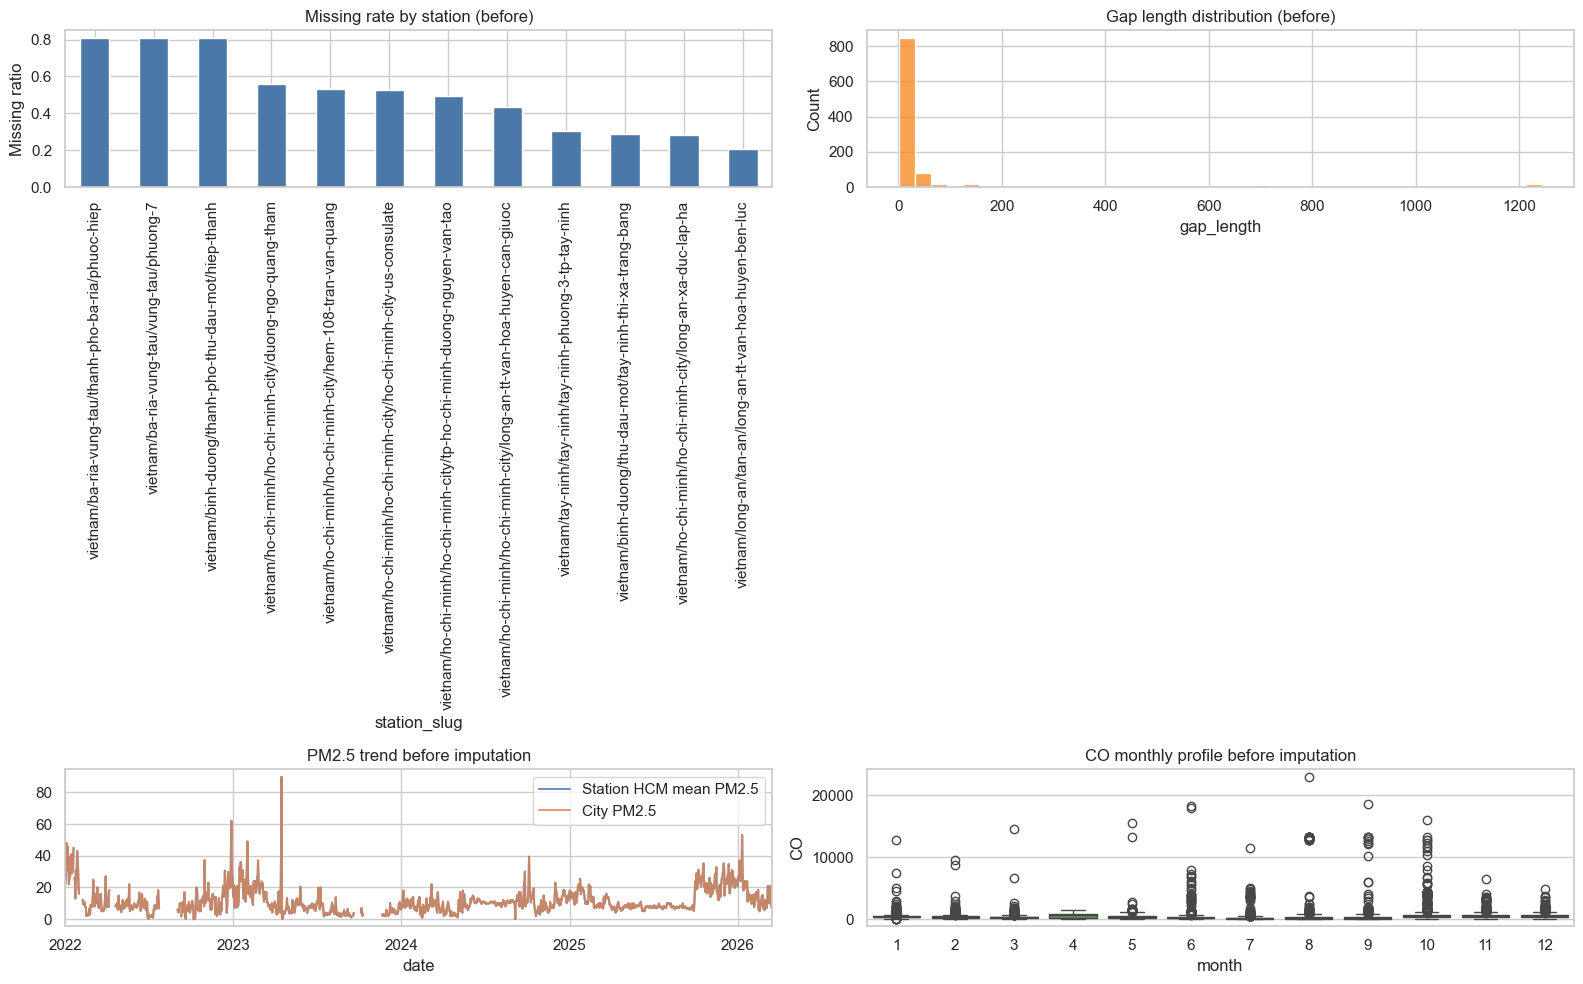

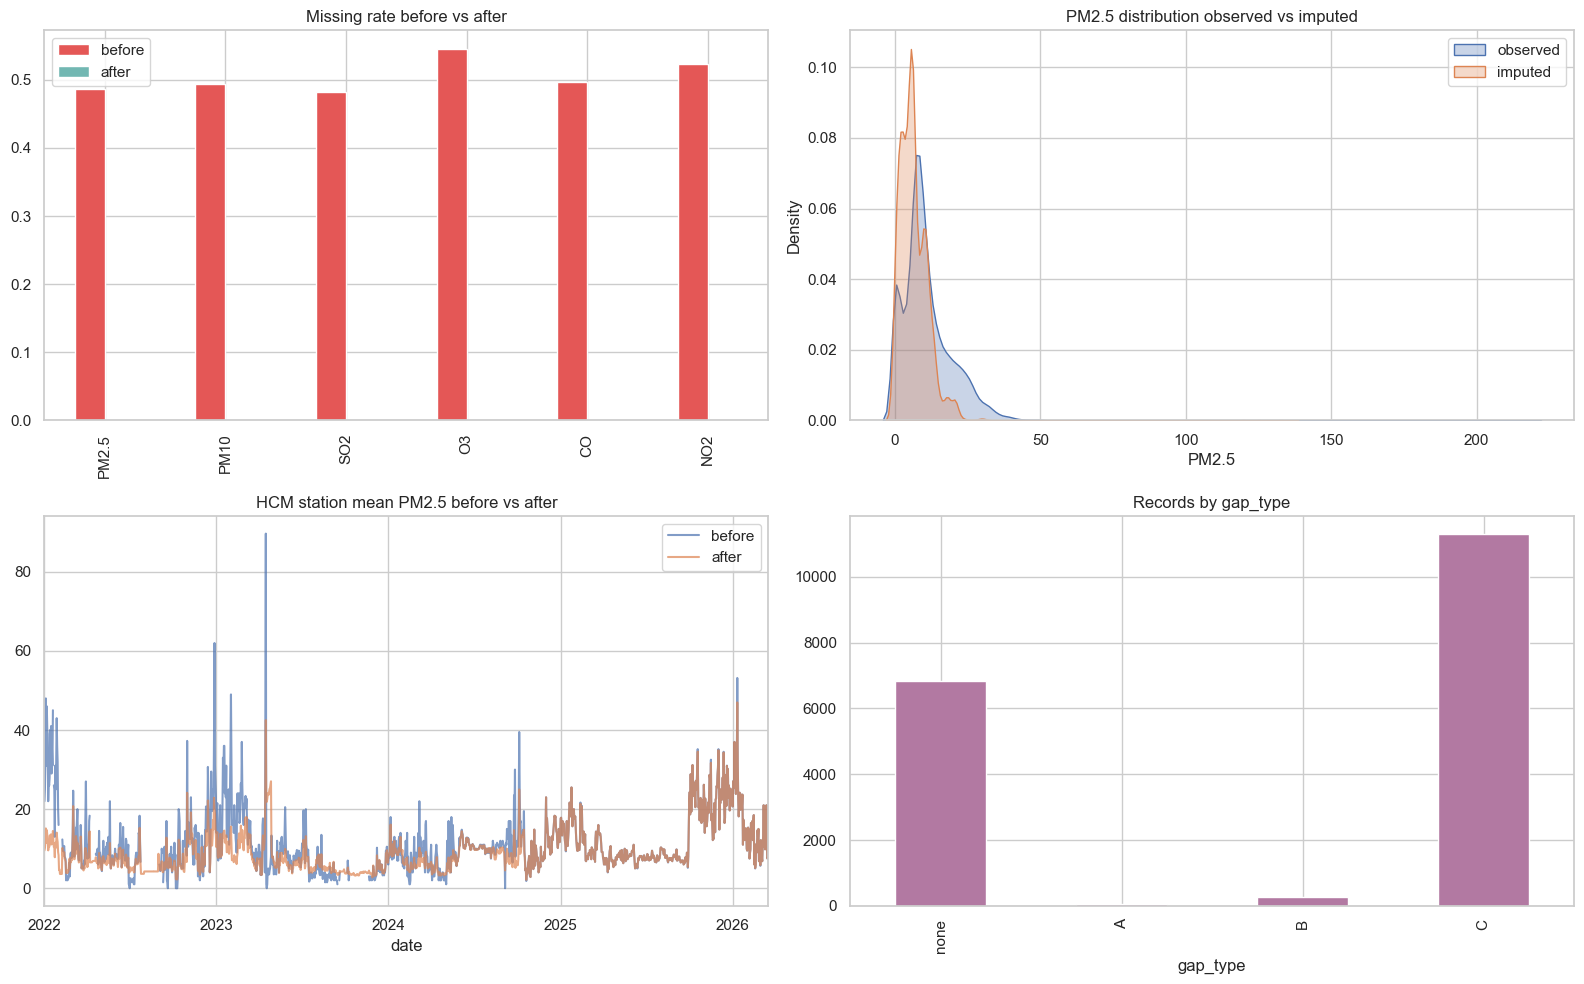

Imputation finished.
Remaining NaN (pollutants): 0
  pollutant      corr         mae status
0     PM2.5  0.777666    2.334309   WARN
1      PM10  0.901305    4.206806     OK
2       SO2  0.920755    4.287490     OK
3        O3  0.589918    5.985148   WARN
4        CO  0.860902  173.550545     OK
5       NO2  0.846331    2.263034     OK


,station_slug,station_name,latitude,longitude,year,date,PM2.5,PM10,SO2,O3,CO,NO2,AQI,used_city_feature,imputed_PM2.5,imputed_PM10,imputed_SO2,imputed_O3,imputed_CO,imputed_NO2,aqi_reconstructed,gap_length_PM2.5,gap_type_PM2.5,gap_length_PM10,gap_type_PM10,gap_length_SO2,gap_type_SO2,gap_length_O3,gap_type_O3,gap_length_CO,gap_type_CO,gap_length_NO2,gap_type_NO2,gap_length,gap_type,station_tier,is_spike_PM2.5,is_spike_PM10,is_spike_SO2,is_spike_O3,is_spike_CO,is_spike_NO2
0,vietnam/ba-ria-vung-tau/thanh-pho-ba-ria/phuoc...,Phuoc Hiep,10.5024,107.169,2022,2022-01-01,11.0,28.6,4.0,28.6,213.3,5.0,2.189544,False,True,True,True,True,True,True,True,1244,C,1244,C,1244,C,1244,C,1244,C,1244,C,1244,C,C,False,False,False,False,False,False
1,vietnam/ba-ria-vung-tau/thanh-pho-ba-ria/phuoc...,Phuoc Hiep,10.5024,107.169,2022,2022-01-02,11.0,28.6,4.0,28.6,213.3,5.0,3.810620,False,True,True,True,True,True,True,True,1244,C,1244,C,1244,C,1244,C,1244,C,1244,C,1244,C,C,False,False,False,False,False,False
2,vietnam/ba-ria-vung-tau/thanh-pho-ba-ria/phuoc...,Phuoc Hiep,10.5024,107.169,2022,2022-01-03,11.0,28.6,4.0,28.6,213.3,5.0,7.052774,False,True,True,True,True,True,True,True,1244,C,1244,C,1244,C,1244,C,1244,C,1244,C,1244,C,C,False,False,False,False,False,False


In [15]:
imputed_df, gap_profile_df, tier_df = run_imputation_pipeline(df_station_raw, df_city_raw, cfg)

city_metrics_df, city_compare_df = validate_city_trend(imputed_df, df_city_raw, cfg)

print("Imputation finished.")
print("Remaining NaN (pollutants):", int(imputed_df[list(cfg.pollutants)].isna().sum().sum()))
print(city_metrics_df)

imputed_df.head(3)

## 6) Add Assertions and Basic Unit Checks

In [16]:
def collect_validation_metrics(df_imputed: pd.DataFrame, df_original: pd.DataFrame, cfg: Config) -> Dict[str, object]:
    metrics = {}
    metrics["remaining_nan_pollutants"] = int(df_imputed[list(cfg.pollutants)].isna().sum().sum())
    metrics["negative_counts"] = {c: int((df_imputed[c] < 0).sum()) for c in cfg.pollutants}

    ks = {}
    for c in cfg.pollutants:
        obs = df_original[c].dropna()
        imp = df_imputed.loc[df_imputed.get(f"imputed_{c}", False), c].dropna()
        if len(obs) >= 30 and len(imp) >= 10:
            stat, p = ks_2samp(obs, imp)
            ks[c] = {"stat": float(stat), "p": float(p), "status": "OK" if p > 0.05 else "WARN"}
    metrics["ks"] = ks

    rate_by_tier = {}
    for t in ["A", "B", "C"]:
        block = df_imputed[df_imputed["station_tier"] == t]
        if len(block) == 0:
            continue
        rate_by_tier[t] = {c: float(block[f"imputed_{c}"].mean()) for c in cfg.pollutants}
    metrics["imputation_rate_by_tier"] = rate_by_tier

    return metrics


metrics = collect_validation_metrics(imputed_df, df_station_raw, cfg)

assert (imputed_df[cfg.date_col].max() <= IMPUTE_UNTIL_TS), "Output contains dates beyond imputation window"
assert all(f"imputed_{c}" in imputed_df.columns for c in cfg.pollutants), "Missing imputed flags"
assert all(f"gap_type_{c}" in imputed_df.columns for c in cfg.pollutants), "Missing per-pollutant gap_type"
assert all(f"gap_length_{c}" in imputed_df.columns for c in cfg.pollutants), "Missing per-pollutant gap_length"
assert "used_city_feature" in imputed_df.columns, "Missing used_city_feature"
assert "gap_type" in imputed_df.columns and "station_tier" in imputed_df.columns, "Missing quality metadata"

print("Assertions passed.")
print(json.dumps(metrics, indent=2)[:2000])

Assertions passed.
{
  "remaining_nan_pollutants": 0,
  "negative_counts": {
    "PM2.5": 0,
    "PM10": 0,
    "SO2": 0,
    "O3": 0,
    "CO": 0,
    "NO2": 0
  },
  "ks": {
    "PM2.5": {
      "stat": 0.3577914057656718,
      "p": 0.0,
      "status": "WARN"
    },
    "PM10": {
      "stat": 0.3028826051815939,
      "p": 0.0,
      "status": "WARN"
    },
    "SO2": {
      "stat": 0.3718263670115725,
      "p": 0.0,
      "status": "WARN"
    },
    "O3": {
      "stat": 0.3798600014964998,
      "p": 0.0,
      "status": "WARN"
    },
    "CO": {
      "stat": 0.2698246982887902,
      "p": 6.149340931464769e-296,
      "status": "WARN"
    },
    "NO2": {
      "stat": 0.36716324901537,
      "p": 0.0,
      "status": "WARN"
    }
  },
  "imputation_rate_by_tier": {
    "A": {
      "PM2.5": 0.38925010836584306,
      "PM10": 0.3511053315994798,
      "SO2": 0.2598612917208496,
      "O3": 0.38372345036844385,
      "CO": 0.28890333766796705,
      "NO2": 0.3379930645860425
 

## 7) Log Results and Export Artifacts

In [ ]:
safe_cfg = asdict(cfg).copy()
if "mongo_uri" in safe_cfg and safe_cfg["mongo_uri"]:
    safe_cfg["mongo_uri"] = "***redacted***"

run_meta = {
    "run_timestamp": datetime.now().isoformat(timespec="seconds"),
    "config": safe_cfg,
    "rows_input_station": int(len(df_station_raw)),
    "rows_output": int(len(imputed_df)),
    "metrics": metrics,
}

imputed_df.to_csv(cfg.output_csv, index=False)
imputed_df.drop(columns=["_id"], errors="ignore").to_parquet(cfg.output_parquet, index=False)
city_compare_df.to_csv(cfg.city_compare_csv, index=False)

with open(cfg.metrics_json, "w", encoding="utf-8") as f:
    json.dump(run_meta, f, ensure_ascii=False, indent=2)

print("Saved artifacts:")
print("-", cfg.output_csv)
print("-", cfg.output_parquet)
print("-", cfg.city_compare_csv)
print("-", cfg.metrics_json)

Saved artifacts:
- hcmc_imputed_output_v2_20260318.csv
- hcmc_imputed_output_v2_20260318.parquet
- city_trend_comparison_v2_20260318.csv
- imputation_metrics_v2_20260318.json


### Optional: MongoDB Writeback (Manual Approval Gate)
Cell dưới đây chỉ ghi dữ liệu khi bạn chủ động đặt `cfg.approve_mongo_write = True`.

In [ ]:
from pymongo import MongoClient, UpdateOne
from pymongo.errors import PyMongoError, ServerSelectionTimeoutError

preview_cols = [cfg.station_col, cfg.station_name_col, cfg.date_col] + list(cfg.pollutants) + [cfg.aqi_col, "gap_type", "station_tier", "used_city_feature"]
preview_cols = [c for c in preview_cols if c in imputed_df.columns]

to_write = imputed_df.copy()
to_write[cfg.date_col] = to_write[cfg.date_col].dt.strftime("%Y-%m-%d")
records = to_write.to_dict(orient="records")

print("Write target:", f"{cfg.mongo_db}.{cfg.mongo_collection}" if cfg.mongo_db and cfg.mongo_collection else "<missing env target>")
print("Records prepared:", len(records))
print("Preview:")
display(to_write[preview_cols].head(20))

if not cfg.approve_mongo_write:
    print("\nAPPROVE_MONGO_WRITE is False -> skip writing to MongoDB.")
    print("Set environment variables first: MONGODB_URI, MONGO_TARGET_DB_NAME, MONGO_TARGET_COLLECTION_NAME")
else:
    missing_env = [
        name for name, value in [
            ("MONGODB_URI", cfg.mongo_uri),
            ("MONGO_TARGET_DB_NAME", cfg.mongo_db),
            ("MONGO_TARGET_COLLECTION_NAME", cfg.mongo_collection),
        ] if not value
    ]
    if missing_env:
        raise RuntimeError(
            "Missing required environment variables for Mongo write: " + ", ".join(missing_env)
        )

    client = None
    try:
        client = MongoClient(
            cfg.mongo_uri,
            serverSelectionTimeoutMS=5000,
            connectTimeoutMS=5000,
            socketTimeoutMS=5000,
            retryWrites=True,
        )
        # Fast fail if server is unavailable
        client.admin.command("ping")

        col = client[cfg.mongo_db][cfg.mongo_collection]

        ops = []
        success = 0
        for r in records:
            filt = {cfg.station_col: r.get(cfg.station_col), cfg.date_col: r.get(cfg.date_col)}
            ops.append(UpdateOne(filt, {"$set": r}, upsert=True))
            if len(ops) >= cfg.mongo_batch_size:
                res = col.bulk_write(ops, ordered=False)
                success += res.upserted_count + res.modified_count
                ops = []

        if ops:
            res = col.bulk_write(ops, ordered=False)
            success += res.upserted_count + res.modified_count

        total_docs = col.count_documents({})
        min_doc = col.find_one(sort=[(cfg.date_col, 1)])
        max_doc = col.find_one(sort=[(cfg.date_col, -1)])

        write_summary = {
            "timestamp": datetime.now().isoformat(timespec="seconds"),
            "target": f"{cfg.mongo_db}.{cfg.mongo_collection}",
            "records_prepared": len(records),
            "bulk_write_ack": int(success),
            "collection_count_after": int(total_docs),
            "min_date_after": None if min_doc is None else min_doc.get(cfg.date_col),
            "max_date_after": None if max_doc is None else max_doc.get(cfg.date_col),
        }

        summary_file = "mongo_write_summary_v2_20260318.json"
        with open(summary_file, "w", encoding="utf-8") as f:
            json.dump(write_summary, f, ensure_ascii=False, indent=2)

        print("Mongo write completed.")
        print(json.dumps(write_summary, indent=2))
        print("Summary saved:", summary_file)

    except ServerSelectionTimeoutError as e:
        print("\nMongoDB connection failed.")
        print("Reason:", str(e))
        print("Hint: Ensure MongoDB service/container is running and env vars are set correctly, then rerun this cell.")

    except PyMongoError as e:
        print("\nMongoDB write failed due to PyMongo error:")
        print(str(e))

    except Exception as e:
        print("\nUnexpected error during Mongo write:")
        print(str(e))

    finally:
        if client is not None:
            try:
                client.close()
            except Exception:
                pass

Write target: airquality_imputed.air_daily_imputed
Records prepared: 18456
Preview:


,station_slug,station_name,date,PM2.5,PM10,SO2,O3,CO,NO2,AQI,gap_type,station_tier,used_city_feature
0,vietnam/ba-ria-vung-tau/thanh-pho-ba-ria/phuoc...,Phuoc Hiep,2022-01-01,11.0,28.6,4.0,28.6,213.3,5.0,2.189544,C,C,False
1,vietnam/ba-ria-vung-tau/thanh-pho-ba-ria/phuoc...,Phuoc Hiep,2022-01-02,11.0,28.6,4.0,28.6,213.3,5.0,3.810620,C,C,False
2,vietnam/ba-ria-vung-tau/thanh-pho-ba-ria/phuoc...,Phuoc Hiep,2022-01-03,11.0,28.6,4.0,28.6,213.3,5.0,7.052774,C,C,False
3,vietnam/ba-ria-vung-tau/thanh-pho-ba-ria/phuoc...,Phuoc Hiep,2022-01-04,11.0,28.6,4.0,28.6,213.3,5.0,16.238875,C,C,False
4,vietnam/ba-ria-vung-tau/thanh-pho-ba-ria/phuoc...,Phuoc Hiep,2022-01-05,11.0,28.6,4.0,28.6,213.3,5.0,7.052774,C,C,False
5,vietnam/ba-ria-vung-tau/thanh-pho-ba-ria/phuoc...,Phuoc Hiep,2022-01-06,11.0,28.6,4.0,28.6,213.3,5.0,15.158158,C,C,False
6,vietnam/ba-ria-vung-tau/thanh-pho-ba-ria/phuoc...,Phuoc Hiep,2022-01-07,11.0,28.6,4.0,28.6,213.3,5.0,11.916004,C,C,False
7,vietnam/ba-ria-vung-tau/thanh-pho-ba-ria/phuoc...,Phuoc Hiep,2022-01-08,11.0,28.6,4.0,28.6,213.3,5.0,11.375645,C,C,False
8,vietnam/ba-ria-vung-tau/thanh-pho-ba-ria/phuoc...,Phuoc Hiep,2022-01-09,11.0,28.6,4.0,28.6,213.3,5.0,2.189544,C,C,False
9,vietnam/ba-ria-vung-tau/thanh-pho-ba-ria/phuoc...,Phuoc Hiep,2022-01-10,11.0,28.6,4.0,28.6,213.3,5.0,4.891338,C,C,False



MongoDB connection failed.
URI: mongodb://localhost:27017
Reason: localhost:27017: [WinError 10061] No connection could be made because the target machine actively refused it (configured timeouts: socketTimeoutMS: 5000.0ms, connectTimeoutMS: 5000.0ms), Timeout: 5.0s, Topology Description: <TopologyDescription id: 69bc0ed28a12b0624ba1bc88, topology_type: Unknown, servers: [<ServerDescription ('localhost', 27017) server_type: Unknown, rtt: None, error=AutoReconnect('localhost:27017: [WinError 10061] No connection could be made because the target machine actively refused it (configured timeouts: socketTimeoutMS: 5000.0ms, connectTimeoutMS: 5000.0ms)')>]>
Hint: Ensure MongoDB service/container is running and URI is correct, then rerun this cell.
